In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/imdevskp/corona-virus-report


In [2]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path


INPUT_FILE = "/kaggle/input/datasets/imdevskp/corona-virus-report/covid_19_clean_complete.csv"
COUNTRY = "Bangladesh"

# IMPORTANT:
# Use the actual total population of the selected country.
# This value is the 2020 population used for the Bangladesh example.
N = 164_689_383

OUTPUT_DIR = Path("/kaggle/working/")

CSV_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.csv"
EXCEL_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.xlsx"
METRICS_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_metrics.csv"

PLOT_S = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_S_observed_vs_rk4.png"
PLOT_I = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_I_observed_vs_rk4.png"
PLOT_R = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_R_observed_vs_rk4.png"

# Read COVID19 Data

In [3]:
df = pd.read_csv(INPUT_FILE)

required_columns = [
    "Country/Region", "Date", "Confirmed",
    "Deaths", "Recovered", "Active"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"])

data = df[df["Country/Region"].eq(COUNTRY)].copy()

if data.empty:
    raise ValueError(
        f"No data found for '{COUNTRY}'. "
        f"Check the COUNTRY variable."
    )

# If the country has province/state rows, aggregate them by date.
data = (
    data.groupby("Date", as_index=False)
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)


## Construct observed S, I, R
Active = I
Recovered + Deaths = R (removed)
S = N - I - R
Note: deaths are included in R because the classical SIR has a single removed compartment.

In [4]:
# ============================================================
# Construct observed S, I, R
# ============================================================

data["I_obs"] = data["Active"].astype(float)
data["R_obs"] = (
    data["Recovered"].astype(float)
    + data["Deaths"].astype(float)
)
data["S_obs"] = N - data["I_obs"] - data["R_obs"]

if (data["S_obs"] < 0).any():
    raise ValueError(
        "Some S_obs values are negative. "
        "Increase/correct N for the selected country."
    )

# The dataset begins with zero active infections.
# Start estimation at the first day with I > 0.
positive_indices = np.flatnonzero(
    data["I_obs"].to_numpy() > 0
)

if len(positive_indices) == 0:
    raise ValueError("No positive Active-infection observations found.")

start_idx = int(positive_indices[0])

fit_data = data.iloc[start_idx:].copy().reset_index(drop=True)

S_obs = fit_data["S_obs"].to_numpy(dtype=float)
I_obs = fit_data["I_obs"].to_numpy(dtype=float)
R_obs = fit_data["R_obs"].to_numpy(dtype=float)

t = np.arange(len(fit_data), dtype=float)

# Initial SIR state
y0 = np.array(
    [S_obs[0], I_obs[0], R_obs[0]],
    dtype=float
)


## Estimate beta and gamma

In [5]:
def sir_rhs(y, beta, gamma, population):
    """
    Normalized SIR equations:
        dS/dt = -beta*S*I/N
        dI/dt =  beta*S*I/N - gamma*I
        dR/dt =  gamma*I
    """
    S, I, R = y

    dS = -beta * S * I / population
    dI = beta * S * I / population - gamma * I
    dR = gamma * I

    return np.array([dS, dI, dR], dtype=float)


def simulate_for_estimation(beta, gamma):
    """
    Numerically integrate SIR during parameter fitting.
    solve_ivp is used only for parameter estimation.
    The final reported solution is produced independently
    with classical RK4 below.
    """
    solution = solve_ivp(
        lambda time, state: sir_rhs(
            state, beta, gamma, N
        ),
        [t[0], t[-1]],
        y0,
        t_eval=t,
        method="RK45",
        rtol=1e-7,
        atol=1e-2
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y


observed = np.vstack([S_obs, I_obs, R_obs])

# Normalize residuals so the very large S compartment does not
# completely dominate I and R during optimization.
scales = np.array([
    max(N, 1.0),
    max(I_obs.max(), 1.0),
    max(R_obs.max(), 1.0)
])


def residual_log_parameters(log_parameters):
    """
    Optimize log(beta), log(gamma), which guarantees
    beta > 0 and gamma > 0.
    """
    beta, gamma = np.exp(log_parameters)

    predicted = simulate_for_estimation(beta, gamma)

    return (
        (predicted - observed)
        / scales[:, None]
    ).ravel()


# Initial guess; change if desired.
initial_guess = np.array([0.30, 0.10])

fit = least_squares(
    residual_log_parameters,
    np.log(initial_guess),
    bounds=(
        np.log([1e-6, 1e-6]),
        np.log([10.0, 10.0])
    ),
    max_nfev=2000
)

beta, gamma = np.exp(fit.x)

# Basic reproduction number for the normalized SIR model.
R0 = beta / gamma

print("\n" + "=" * 70)
print("ESTIMATED SIR PARAMETERS")
print("=" * 70)
print(f"Country        : {COUNTRY}")
print(f"Population N   : {N:,}")
print(f"Start date     : {fit_data['Date'].iloc[0].date()}")
print(f"End date       : {fit_data['Date'].iloc[-1].date()}")
print(f"beta           : {beta:.10f}")
print(f"gamma          : {gamma:.10f}")
print(f"R0 = beta/gamma: {R0:.10f}")
print("=" * 70)


ESTIMATED SIR PARAMETERS
Country        : Bangladesh
Population N   : 164,689,383
Start date     : 2020-03-08
End date       : 2020-07-27
beta           : 0.1715094807
gamma          : 0.0942542420
R0 = beta/gamma: 1.8196473406


# Classical fourth-order Runge-Kutta (RK4) Solution

In [6]:
def rk4_sir(y_initial, beta, gamma, population,
            n_steps, h=1.0):
    """
    Classical fourth-order Runge-Kutta solution
    for the normalized SIR model.
    """

    y = np.array(y_initial, dtype=float)

    result = np.zeros(
        (n_steps + 1, 3),
        dtype=float
    )

    result[0] = y

    def f(state):
        return sir_rhs(
            state,
            beta,
            gamma,
            population
        )

    for step in range(n_steps):

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y = y + (
            h / 6.0
        ) * (
            k1 + 2*k2 + 2*k3 + k4
        )

        # Numerical safeguard.
        y = np.maximum(y, 0.0)

        result[step + 1] = y

    return result


rk4_solution = rk4_sir(
    y_initial=y0,
    beta=beta,
    gamma=gamma,
    population=N,
    n_steps=len(fit_data) - 1,
    h=1.0
)

fit_data["S_RK4"] = rk4_solution[:, 0]
fit_data["I_RK4"] = rk4_solution[:, 1]
fit_data["R_RK4"] = rk4_solution[:, 2]

## Complete S, I, R values for every day

In [7]:
results = fit_data[
    [
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active",
        "S_obs",
        "I_obs",
        "R_obs",
        "S_RK4",
        "I_RK4",
        "R_RK4"
    ]
].copy()


# ============================================================
# 5. SAVE CSV AND EXCEL
# ============================================================

results.to_csv(
    CSV_FILE,
    index=False
)

metrics_rows = []

for compartment, observed_column, rk4_column in [
    ("S", "S_obs", "S_RK4"),
    ("I", "I_obs", "I_RK4"),
    ("R", "R_obs", "R_RK4")
]:

    y_true = results[observed_column].to_numpy()
    y_pred = results[rk4_column].to_numpy()

    mae = mean_absolute_error(
        y_true, y_pred
    )

    mse = mean_squared_error(
        y_true, y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true, y_pred
    )

    metrics_rows.append({
        "Compartment": compartment,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

metrics = pd.DataFrame(metrics_rows)

parameter_table = pd.DataFrame({
    "Parameter": [
        "Country",
        "Population_N",
        "beta",
        "gamma",
        "R0",
        "Start_Date",
        "End_Date"
    ],
    "Value": [
        COUNTRY,
        N,
        beta,
        gamma,
        R0,
        str(results["Date"].iloc[0].date()),
        str(results["Date"].iloc[-1].date())
    ]
})

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="SIR_RK4_Results",
        index=False
    )

    metrics.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    parameter_table.to_excel(
        writer,
        sheet_name="Parameters",
        index=False
    )

metrics.to_csv(
    METRICS_FILE,
    index=False
)

## Plot Observed Data VS RK4 Solved Data 
Three separate figures are used because S is much larger than I and R and would otherwise hide their differences.

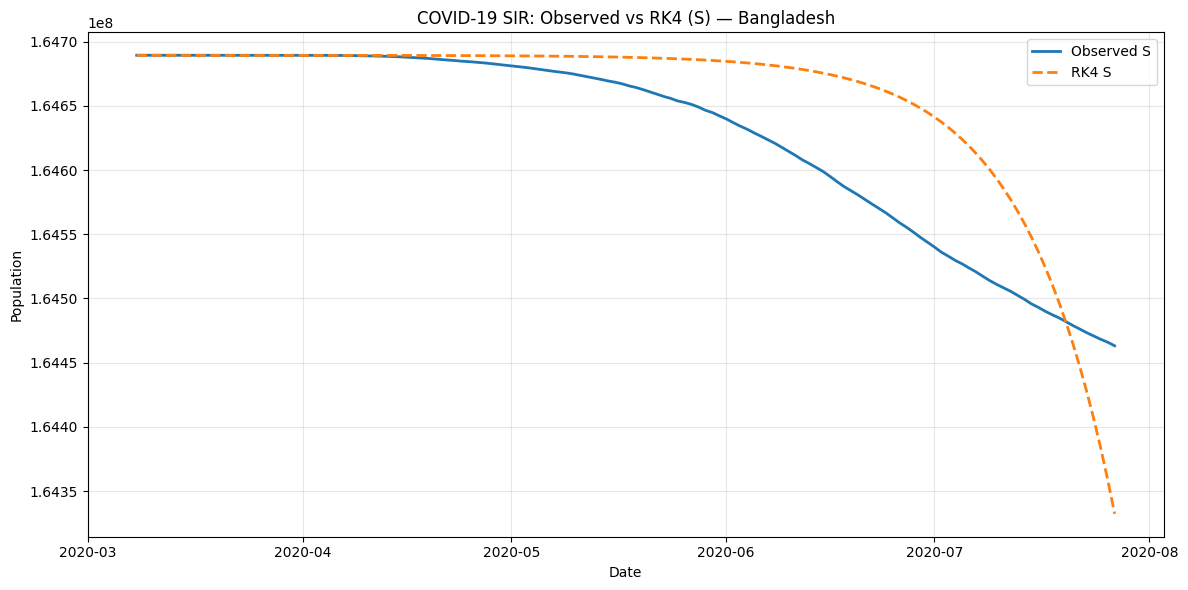

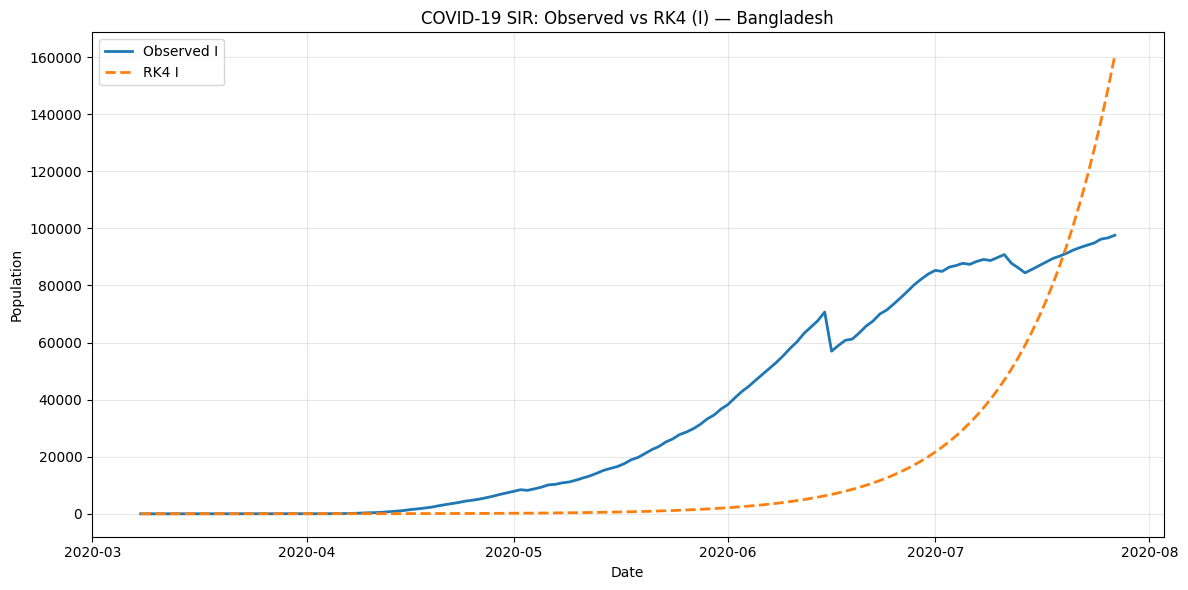

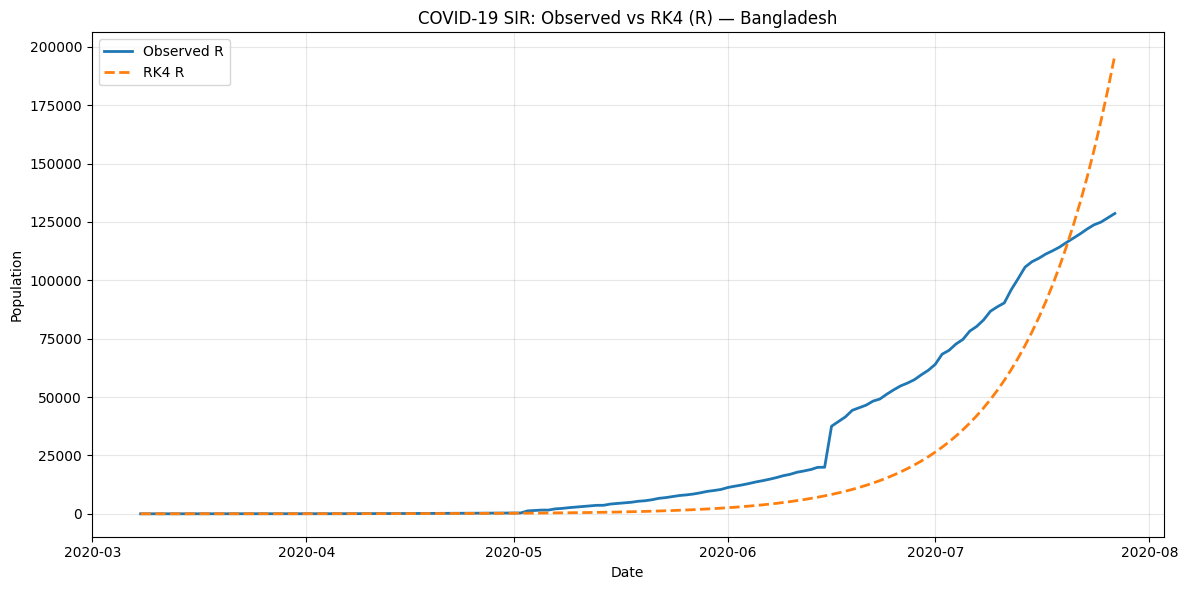


MODEL PERFORMANCE
Compartment           MAE                  MSE          RMSE       R2
          S 34,521.622536 2,550,213,550.984175 50,499.639117 0.522849
          I 22,818.473300 1,050,476,888.634334 32,411.061208 0.168832
          R 11,727.681623   375,884,687.230241 19,387.745801 0.756780


First 10 RK4 results:
      Date       S_obs        S_RK4  I_obs    I_RK4  R_obs    R_RK4
2020-03-08 164689380.0 1.646894e+08    3.0 3.000000    0.0 0.000000
2020-03-09 164689380.0 1.646894e+08    3.0 3.240953    0.0 0.293972
2020-03-10 164689380.0 1.646894e+08    3.0 3.501259    0.0 0.611555
2020-03-11 164689380.0 1.646894e+08    3.0 3.782473    0.0 0.954646
2020-03-12 164689380.0 1.646894e+08    3.0 4.086272    0.0 1.325292
2020-03-13 164689380.0 1.646894e+08    3.0 4.414473    0.0 1.725709
2020-03-14 164689380.0 1.646894e+08    3.0 4.769033    0.0 2.158286
2020-03-15 164689378.0 1.646894e+08    5.0 5.152071    0.0 2.625606
2020-03-16 164689375.0 1.646894e+08    6.0 5.565874    2.0 3.1304

In [8]:
def make_comparison_plot(
    date,
    observed_values,
    rk4_values,
    compartment,
    filename
):

    plt.figure(figsize=(12, 6))

    plt.plot(
        date,
        observed_values,
        label=f"Observed {compartment}",
        linewidth=2
    )

    plt.plot(
        date,
        rk4_values,
        "--",
        label=f"RK4 {compartment}",
        linewidth=2
    )

    plt.xlabel("Date")
    plt.ylabel("Population")
    plt.title(
        f"COVID-19 SIR: Observed vs RK4 "
        f"({compartment}) — {COUNTRY}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


make_comparison_plot(
    results["Date"],
    results["S_obs"],
    results["S_RK4"],
    "S",
    PLOT_S
)

make_comparison_plot(
    results["Date"],
    results["I_obs"],
    results["I_RK4"],
    "I",
    PLOT_I
)

make_comparison_plot(
    results["Date"],
    results["R_obs"],
    results["R_RK4"],
    "R",
    PLOT_R
)


# ============================================================
# 7. PRINT METRICS
# ============================================================

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(
    metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:,.6f}"
    )
)

print("\n" + "=" * 70)
print("\nFirst 10 RK4 results:")
print("=" * 70)
print(
    results[
        [
            "Date",
            "S_obs",
            "S_RK4",
            "I_obs",
            "I_RK4",
            "R_obs",
            "R_RK4"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)
print(f"CSV     : {CSV_FILE}")
print(f"Excel   : {EXCEL_FILE}")
print(f"Metrics : {METRICS_FILE}")
print(f"S plot  : {PLOT_S}")
print(f"I plot  : {PLOT_I}")
print(f"R plot  : {PLOT_R}")
print("=" * 70)

# COVID-19 SEIR RK4-FNN Synthetic Experiment
#### Method:
1. Generate synthetic SEIR data using RK4
2. Min-Max normalization
3. 80/20 train-validation split
4. FNN input = t
5. FNN output = [S(t), E(t), I(t), R(t)]
6. MSE loss
7. Adam optimizer
8. tanh activation
9. 150 epochs

 SEIR compartments:
   S = Susceptible
   E = Exposed
   I = Infectious
   R = Recovered

In [9]:
import os, random
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Output directory

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# SEIR PARAMETERS
BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# TIME SETTINGS
T0 = 0.0
T1 = 5000.0
H = 0.5


# FNN SETTINGS
SEED = 42
EPOCHS = 200
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 32, 256, 128, 80, 40, 16]


# RANDOM SEED
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

## SEIR Differential Equations
The SEIR model is a standard epidemiological framework that splits a total constant population (N) into four compartments: Susceptible (S), Exposed (E), Infectious (I), and Removed/Recovered (R).

The standard system of ordinary differential equations (ODEs) governing the continuous-time dynamics of an SEIR epidemic is defined as follows:

\begin{aligned}\frac{dS}{dt}&=-\beta \frac{SI}{N}\\ \frac{dE}{dt}&=\beta \frac{SI}{N}-\sigma E\\ \frac{dI}{dt}&=\sigma E-\gamma I\\ \frac{dR}{dt}&=\gamma I\end{aligned}

In [10]:
def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])

## RK4 Synthetic Data Generation

In [11]:
# ============================================================
# RK4 Setup
# ============================================================
def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)

## Build and Run FNN Model

In [12]:
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)

2026-09-04 17:43:16.331248: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Compile FNN MODEL

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())

Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,204 (219.55 KB)

 Trainable params: 56,204 (219.55 KB)

 Non-trainable params: 0 (0.00 B)

None


## Train FNN

In [14]:
from tensorflow import keras
from tensorflow.keras import callbacks

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUT.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUT / "best_COVID19_SEIR_FNN.keras"

print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Best model will be saved to:
/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method/best_COVID19_SEIR_FNN.keras


In [15]:
# ============================================================
# MODEL CHECKPOINT
# ============================================================

checkpoint = callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [16]:
# ============================================================
# TRAINING
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[checkpoint],
    verbose=1
)


# ============================================================
# CHECK WHETHER BEST MODEL EXISTS
# ============================================================

if BEST_MODEL_PATH.exists():
    print("\n✓ Best model successfully saved:")
    print(BEST_MODEL_PATH)
else:
    raise FileNotFoundError(
        f"\n✗ Best model was NOT created:\n{BEST_MODEL_PATH}"
    )


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(hist.history)

Hdf.insert(
    0,
    "epoch",
    np.arange(1, len(Hdf) + 1)
)

Hdf.to_csv(
    OUT / "FNN_training_history.csv",
    index=False
)


Epoch 1/200
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0247 - mae: 0.0746

2026-09-04 17:43:20.081584: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from None to 0.00605, saving model to /kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method/best_COVID19_SEIR_FNN.keras

Epoch 1: finished saving model to /kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method/best_COVID19_SEIR_FNN.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0134 - mae: 0.0477 - val_loss: 0.0060 - val_mae: 0.0226
Epoch 2/200
242/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0045 - mae: 0.0203
Epoch 2: val_loss improved from 0.00605 to 0.00215, saving model to /kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method/best_COVID19_SEIR_FNN.keras

Epoch 2: finished saving model to /kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method/best_COVID19_SEIR_FNN.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - mae: 0.0174 - val_loss: 0.0022 - val_mae: 0.0141
Epoch 3/200
240/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mae: 0.0105
Epoch 3: val_loss improved from 0.00215 to 0.00033, saving

## FNN Model Evaluation

In [17]:
# ============================================================
# Load the best model developed after training
# ============================================================

best_model = keras.models.load_model(BEST_MODEL_PATH)

In [18]:
# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = best_model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)

# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

 59/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2026-09-04 17:46:30.546555: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment        MAE           MSE       RMSE       R2
          S 327.473893 547493.728184 739.928191 0.999951
          E  17.751915   1629.768180  40.370387 0.999921
          I  55.581012  16212.071995 127.326635 0.999805
          R 701.352236 785206.988285 886.119060 0.999939

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.000443    1.001894e-06              99.955701
          E        0.000325    8.512453e-07              99.967542
          I        0.000345    2.095505e-06              99.965538
          R        0.000943    1.418133e-06              99.905675

Population conservation c

## Plot the results

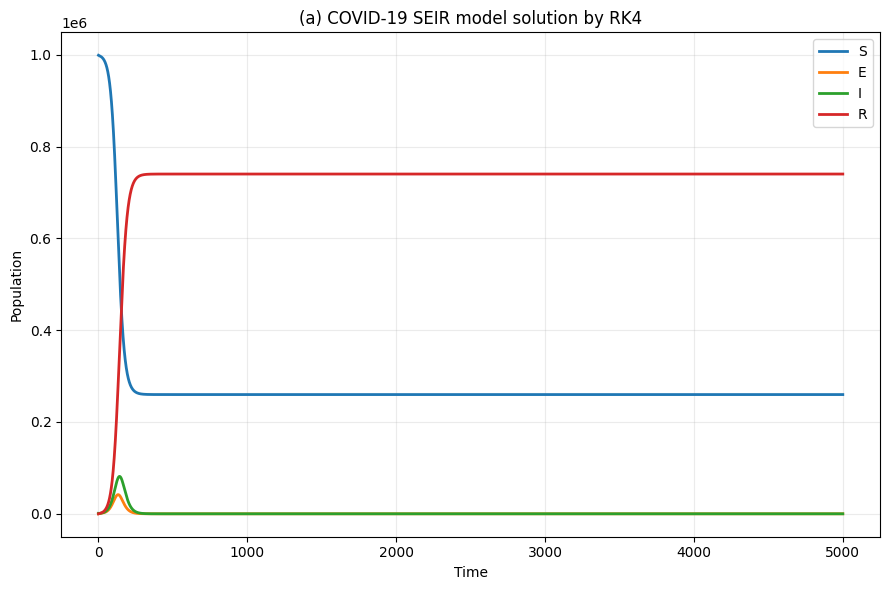

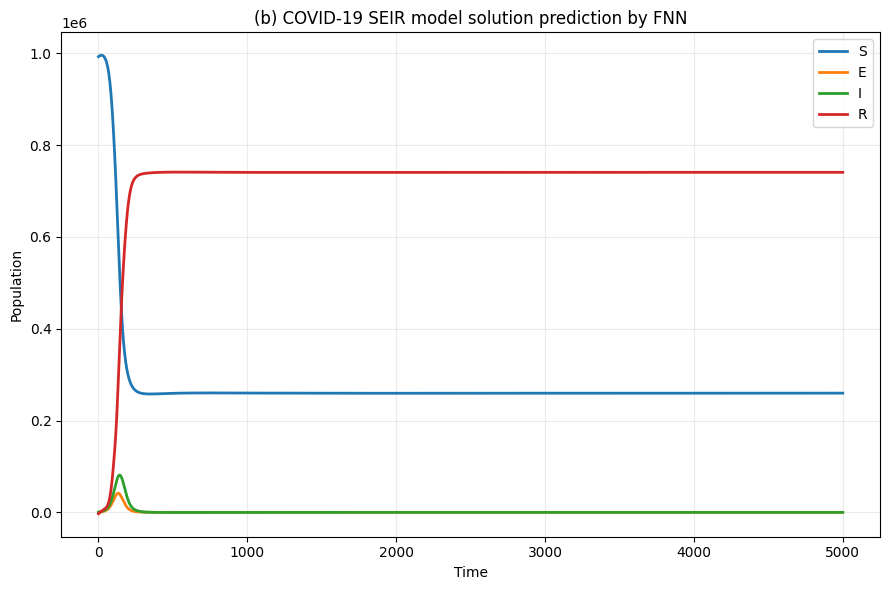

In [19]:
# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

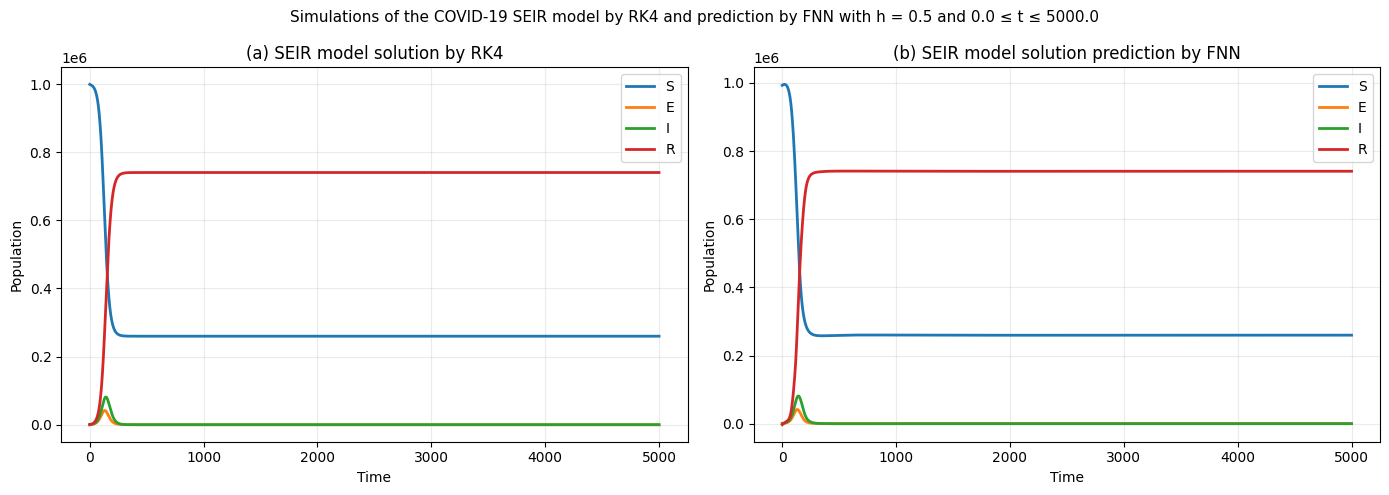

In [20]:
# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

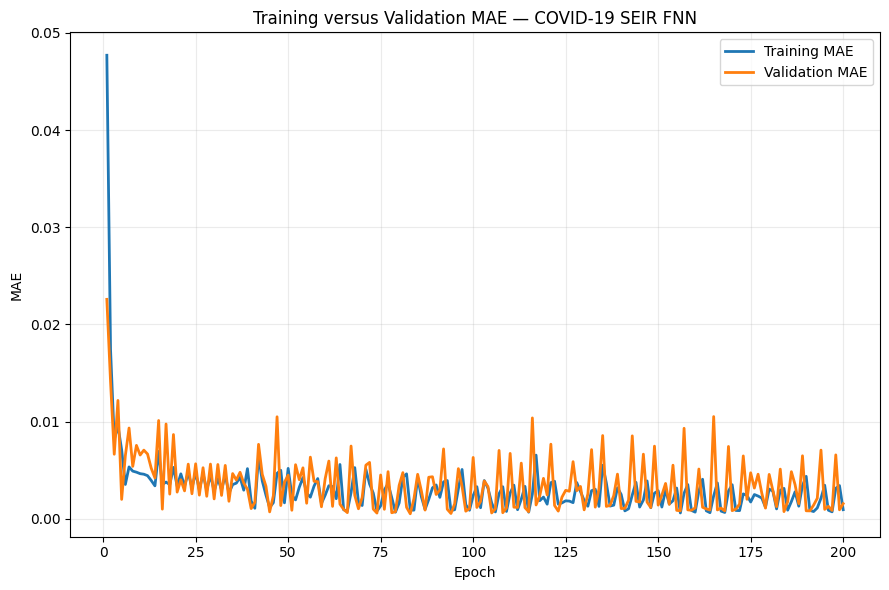

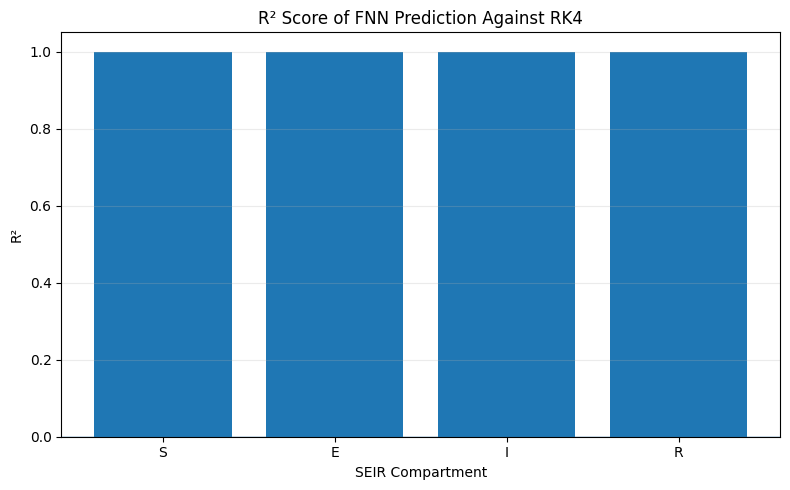

/tmp/ipykernel_16/2482062989.py:204: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_16/2482062989.py:210: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_16/2482062989.py:216: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_16/2482062989.py:222: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_16/2482062989.py:228: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_16/2482062989.py:234: FutureWarning: S

In [21]:
# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )

## Predicted Result by FNN Model

In [22]:
# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

Y_pred_scaled = best_model.predict(
    Xs,
    verbose=0
)

Y_pred = ysc.inverse_transform(
    Y_pred_scaled
)


FNN_pred_S = Y_pred[:, 0]
FNN_pred_I = Y_pred[:, 2]
FNN_pred_R = Y_pred[:, 3]


# ------------------------------------------------------------
# TABLE 10
# ------------------------------------------------------------

print("\nTable 10. Predicted values of S, I, and R by FNN")
print("=" * 105)

print(
    f"{'t':>10}"
    f"{'Predicted S':>22}"
    f"{'Predicted I':>22}"
    f"{'Predicted R':>22}"
)

selected_indices = [
    0,
    1,
    2,
    3,
    4,
    5,
    len(t) - 5,
    len(t) - 4,
    len(t) - 3,
    len(t) - 2,
    len(t) - 1
]

for i in selected_indices:

    print(
        f"{t[i]:10.4f}"
        f"{FNN_pred_S[i]:22.4f}"
        f"{FNN_pred_I[i]:22.4f}"
        f"{FNN_pred_R[i]:22.4f}"
    )

2026-09-04 17:46:42.177548: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Table 10. Predicted values of S, I, and R by FNN
         t           Predicted S           Predicted I           Predicted R
    0.0000           992992.7500              559.6906            -3089.2546
    0.5000           993127.1875              584.2365            -2919.7854
    1.0000           993259.1875              609.0688            -2751.9485
    1.5000           993388.5000              634.2604            -2585.6560
    2.0000           993515.1250              659.7579            -2420.8196
    2.5000           993638.9375              685.6049            -2257.5271
 4998.0000           259769.3438              -14.5211           740904.6875
 4998.5000           259769.4375              -14.5308           740904.7500
 4999.0000           259769.5000              -14.5260           740904.5625
 4999.5000           259769.3594              -14.5308           740904.7500
 5000.0000           259769.4531              -14.5211           740904.6875


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CHECK ARRAY LENGTHS
# ============================================================

print("Array lengths:")
print("dates  :", len(t))
print("S_RK4 :", len(y[:,0]))
print("E_RK4 :", len(y[:,1]))
print("I_RK4 :", len(y[:,2]))
print("R_RK4 :", len(y[:,3]))
print("S_FNN :", len(pred[:,0]))
print("E_FNN :", len(pred[:,1]))
print("I_FNN :", len(pred[:,2]))
print("R_FNN :", len(pred[:,3]))

Array lengths:
dates  : 10001
S_RK4 : 10001
E_RK4 : 10001
I_RK4 : 10001
R_RK4 : 10001
S_FNN : 10001
E_FNN : 10001
I_FNN : 10001
R_FNN : 10001


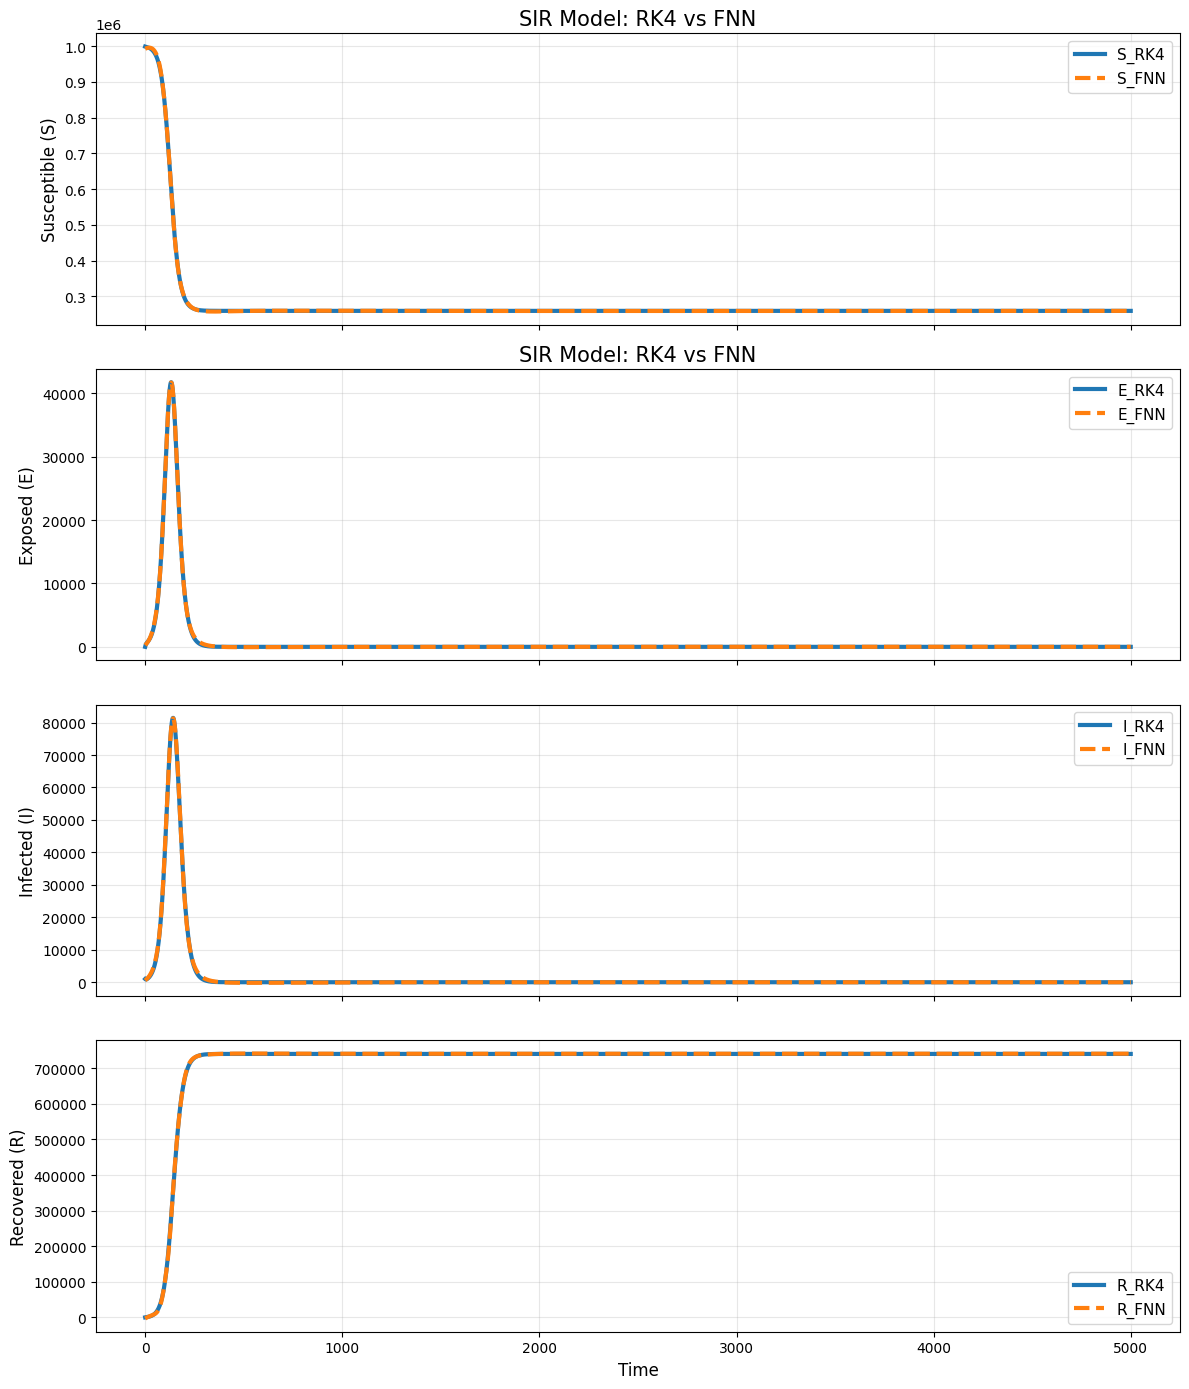

In [24]:
# ============================================================
# MAKE SURE ALL ARRAYS HAVE THE SAME LENGTH
# ============================================================

n = min(
    len(t),
    len(y[:,0]), len(y[:,1]), len(y[:,2]), len(y[:,3]),
    len(pred[:,0]), len(pred[:,1]), len(pred[:,2]), len(pred[:,2])
)

time_plot = np.asarray(t[:n])

S_RK4_plot = np.asarray(y[:,0][:n])
E_RK4_plot = np.asarray(y[:,1][:n])
I_RK4_plot = np.asarray(y[:,2][:n])
R_RK4_plot = np.asarray(y[:,3][:n])

S_FNN_plot = np.asarray(pred[:,0][:n])
E_FNN_plot = np.asarray(pred[:,1][:n])
I_FNN_plot = np.asarray(pred[:,2][:n])
R_FNN_plot = np.asarray(pred[:,3][:n])

# ============================================================
# PLOT RK4 VS FNN
# ============================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

# ------------------------------------------------------------
# S - SUSCEPTIBLE
# ------------------------------------------------------------

axes[0].plot(
    time_plot,
    S_RK4_plot,
    label="S_RK4",
    linewidth=3
)

axes[0].plot(
    time_plot,
    S_FNN_plot,
    label="S_FNN",
    linestyle="--",
    linewidth=3
)

axes[0].set_ylabel("Susceptible (S)", fontsize=12)
axes[0].set_title("SIR Model: RK4 vs FNN", fontsize=15)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------
# E - SUSCEPTIBLE
# ------------------------------------------------------------

axes[1].plot(
    time_plot,
    E_RK4_plot,
    label="E_RK4",
    linewidth=3
)

axes[1].plot(
    time_plot,
    E_FNN_plot,
    label="E_FNN",
    linestyle="--",
    linewidth=3
)

axes[1].set_ylabel("Exposed (E)", fontsize=12)
axes[1].set_title("SIR Model: RK4 vs FNN", fontsize=15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# ------------------------------------------------------------
# I - INFECTED
# ------------------------------------------------------------

axes[2].plot(
    time_plot,
    I_RK4_plot,
    label="I_RK4",
    linewidth=3
)

axes[2].plot(
    time_plot,
    I_FNN_plot,
    label="I_FNN",
    linestyle="--",
    linewidth=3
)

axes[2].set_ylabel("Infected (I)", fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

# ------------------------------------------------------------
# R - RECOVERED
# ------------------------------------------------------------

axes[3].plot(
    time_plot,
    R_RK4_plot,
    label="R_RK4",
    linewidth=3
)

axes[3].plot(
    time_plot,
    R_FNN_plot,
    label="R_FNN",
    linestyle="--",
    linewidth=3
)

axes[3].set_xlabel("Time", fontsize=12)
axes[3].set_ylabel("Recovered (R)", fontsize=12)
axes[3].legend(fontsize=11)
axes[3].grid(True, alpha=0.3)

# ============================================================
# FINAL FORMATTING
# ============================================================

plt.tight_layout()

plt.savefig(
    "SIR_RK4_vs_FNN.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

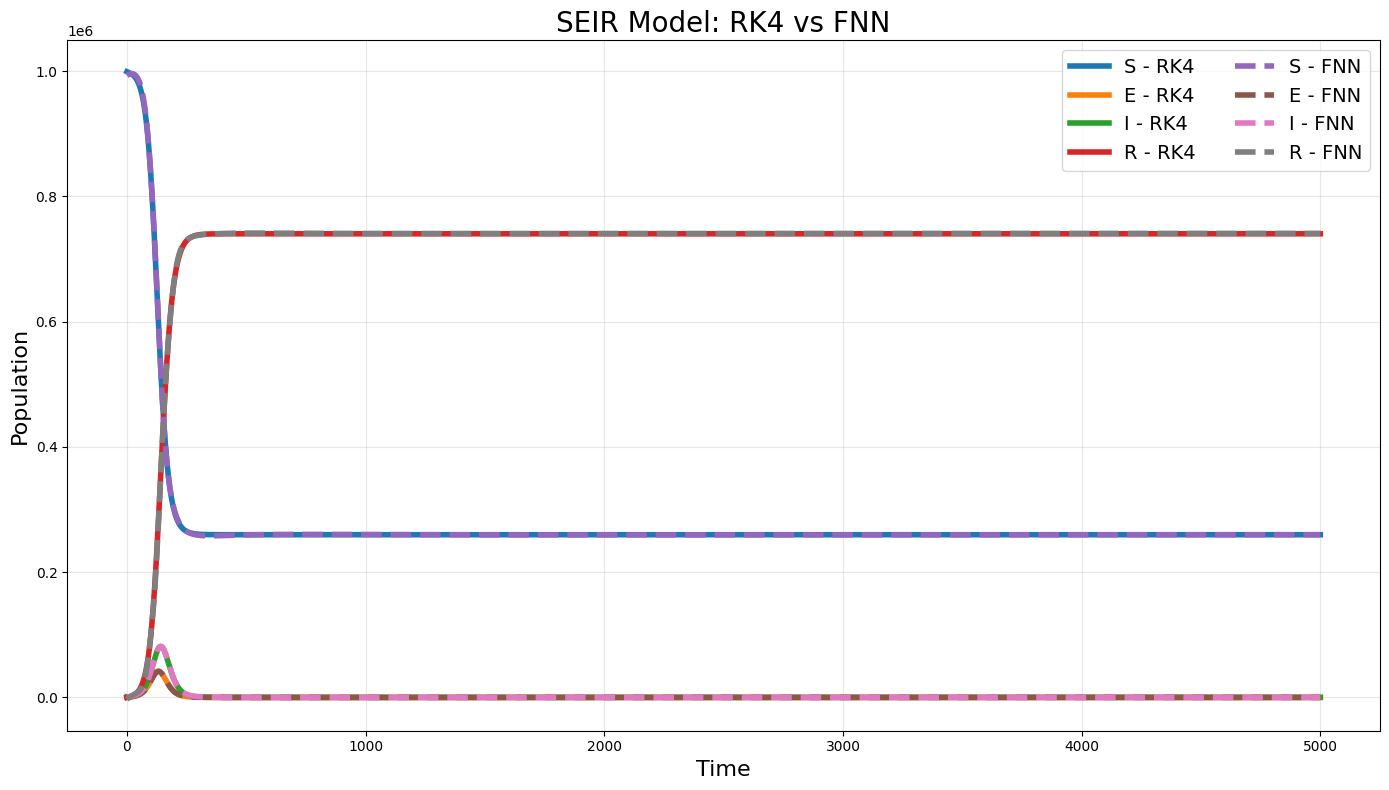

In [25]:
plt.figure(figsize=(14, 8))

# RK4
plt.plot(t, y[:,0], label="S - RK4", linewidth=4)
plt.plot(t, y[:,1], label="E - RK4", linewidth=4)
plt.plot(t, y[:,2], label="I - RK4", linewidth=4)
plt.plot(t, y[:,3], label="R - RK4", linewidth=4)

# FNN
plt.plot(t, pred[:,0], "--", label="S - FNN", linewidth=4)
plt.plot(t, pred[:,1], "--", label="E - FNN", linewidth=4)
plt.plot(t, pred[:,2], "--", label="I - FNN", linewidth=4)
plt.plot(t, pred[:,3], "--", label="R - FNN", linewidth=4)

plt.xlabel("Time", fontsize=16)
plt.ylabel("Population", fontsize=16)
plt.title("SEIR Model: RK4 vs FNN", fontsize=20)

plt.legend(
    ncol=2,
    fontsize=14
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "SEIR_RK4_vs_FNN_same_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()